# 06 — Sensitivity (duplicates), uplift segments (E6)

**Blocks**

| Block | Question | Contract |
|---|---|---|
| A — Dedup sensitivity | Do conclusions survive exact-row deduplication? (duplicates are non-random: E1 found 4.5% of control vs 17.9% of treated rows involved) | Full data stays primary; dedup is a sensitivity read. ITT recomputed; top-10% policy ordering re-checked on deduped validation rows. |
| B — E6 segments | Where does estimated uplift concentrate, and does the observed randomized effect agree with the ranking? | CATE quantile segments (top 10% / 10-25% / 25-50% / 50-75% / bottom 25%); observed slice effects from randomized arms with bootstrap CIs. |

## Block A — Duplicate sensitivity (story corrected after the collision check)

E1's collision check settled the mechanism: treated rows subsampled to control size duplicate at **4.4%**, statistically identical to the control arm's **4.5%**. The 17.9% treated-arm figure is an **arm-size artifact** — the treated arm is ~5.7× larger, and identical feature vectors (real users on the boundary values of quantile-coded features) collide proportionally to group size. Duplicates are therefore **real users, not duplicate storage**.

Consequence: a naive dedup drops mostly zero-outcome treated rows → the treated rate mechanically rises → the ITT is **inflated** (1.034 → 1.493 pp, ≈ +45% relative). The frozen decision stands: **full data stays primary**; dedup is reported as a sensitivity with the corrected interpretation — *"the naive-dedup effect is the artifact, not the full-data effect."*

In [3]:
import json, time, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
import sys
from pathlib import Path
ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT / "src"))
import config as C
import core
import viz
import matplotlib.pyplot as plt
SEED = 42

df = pd.read_parquet(C.DATA / "criteo_uplift_v2_hashed.parquet")
print("full data:", df.shape)


full data: (13979592, 17)


In [ ]:
# Exact-duplicate sensitivity check for pooled ITT estimates.
# Compare treatment/control outcome rates and bootstrap CIs using all rows
# versus a dataset with exact duplicate records removed. This tests whether
# repeated identical rows materially affect the pooled estimates; it is not
# user-level deduplication.

def itt(y):
    y1 = df[y][df[C.TREATMENT] == 1].to_numpy()
    y0 = df[y][df[C.TREATMENT] == 0].to_numpy()
    ate, lo, hi, se = core.ate_bootstrap(y1, y0, n_boot=2000, seed=SEED)
    return dict(rate_t=round(y1.mean() * 100, 4), rate_c=round(y0.mean() * 100, 4),
                itt_pp=round(ate * 100, 4), lo=round(lo * 100, 4), hi=round(hi * 100, 4))

full_itt = {y: itt(y) for y in (C.VISIT, C.CONVERSION)}
content_cols = C.FEATURES + [C.TREATMENT, C.VISIT, C.CONVERSION, C.EXPOSURE]
dd = df.drop_duplicates(subset=content_cols, keep="first")

def itt_dd(yseries, frame):
    y1 = frame[yseries][frame[C.TREATMENT] == 1].to_numpy()
    y0 = frame[yseries][frame[C.TREATMENT] == 0].to_numpy()
    ate, lo, hi, se = core.ate_bootstrap(y1, y0, n_boot=2000, seed=SEED)
    return dict(rate_t=round(y1.mean() * 100, 4), rate_c=round(y0.mean() * 100, 4),
                itt_pp=round(ate * 100, 4), lo=round(lo * 100, 4), hi=round(hi * 100, 4))

dd_itt = {y: itt_dd(y, dd) for y in (C.VISIT, C.CONVERSION)}
rows = []
for y, lab in ((C.VISIT, "visit"), (C.CONVERSION, "conversion")):
    for ver, d in (("full", full_itt[y]), ("dedup", dd_itt[y])):
        rows.append(dict(outcome=lab, version=ver, rate_treated_pp=d["rate_t"],
                         rate_control_pp=d["rate_c"], itt_pp=d["itt_pp"],
                         ci_lo_pp=d["lo"], ci_hi_pp=d["hi"]))
itt_tab = pd.DataFrame(rows)
itt_tab.to_csv(C.TABLES / "e6_dedup_itt_sensitivity.csv", index=False)
print("dedup rows:", len(dd), "| treat ratio dedup:", round(dd[C.TREATMENT].mean(), 5))
itt_tab

dedup rows: 12720047 | treat ratio dedup: 0.839


,outcome,version,rate_treated_pp,rate_control_pp,itt_pp,ci_lo_pp,ci_hi_pp
0,visit,full,4.8543,3.8201,1.0342,1.0060,1.0623
1,visit,dedup,5.4047,3.9116,1.4932,1.4649,1.5228
2,conversion,full,0.3089,0.1938,0.1152,0.1087,0.1221
3,conversion,dedup,0.3440,0.1984,0.1456,0.1389,0.1527


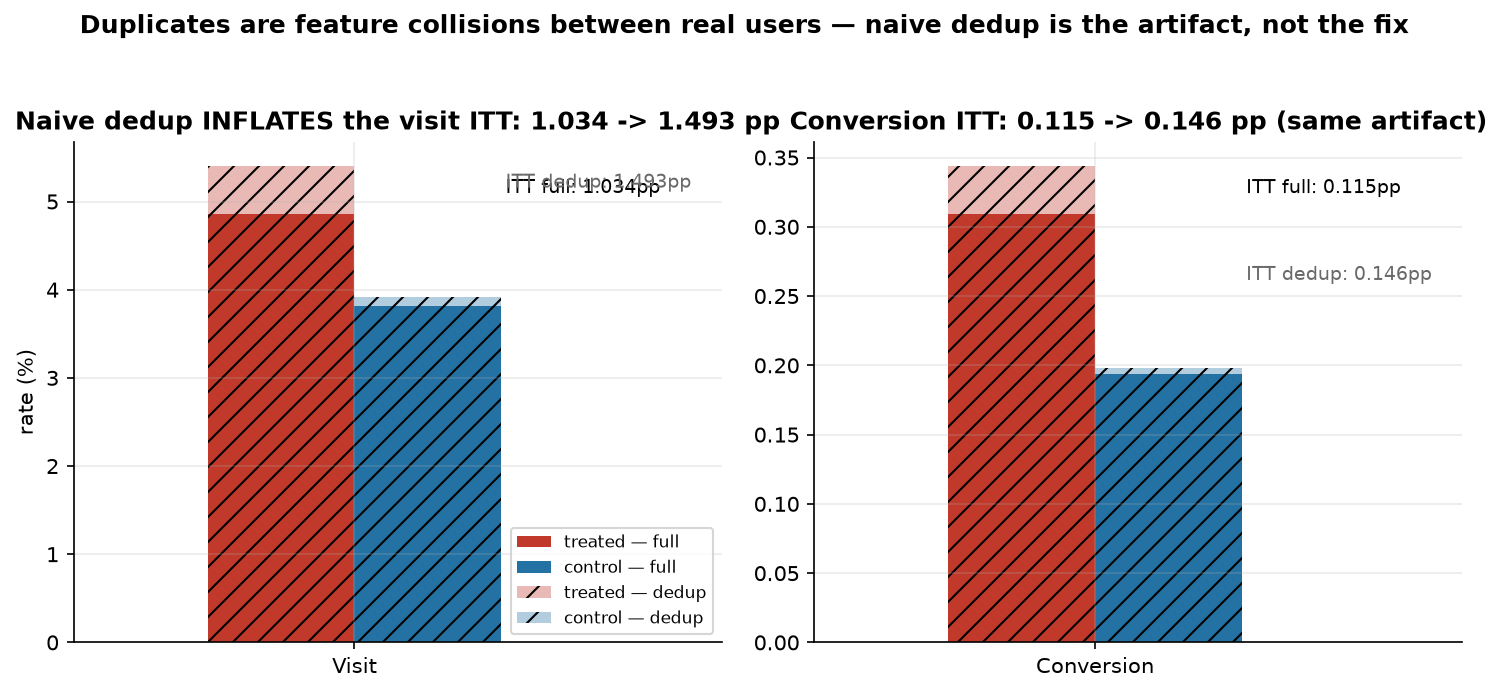

figure saved


In [6]:
# Plot the pooled ITT estimates for full vs dedup datasets, with bootstrap CIs.
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
for ax, ycol in zip(axes, ["visit", "conversion"]):
    sub = itt_tab[itt_tab.outcome == ycol]
    full, dsub = sub[sub.version == "full"], sub[sub.version == "dedup"]
    x = np.arange(1); w = 0.34
    ax.bar([-w/2], full.rate_treated_pp, w, color=viz.COLOR_TREATED, label="treated — full")
    ax.bar([+w/2], full.rate_control_pp, w, color=viz.COLOR_CONTROL, label="control — full")
    ax.bar([-w/2], dsub.rate_treated_pp, w, color=viz.COLOR_TREATED, alpha=0.35, hatch="//", label="treated — dedup")
    ax.bar([+w/2], dsub.rate_control_pp, w, color=viz.COLOR_CONTROL, alpha=0.35, hatch="//", label="control — dedup")
    ax.text(0.35, full.rate_treated_pp.iloc[0]*1.05, f"ITT full: {full.itt_pp.iloc[0]:.3f}pp", fontsize=9)
    ax.text(0.35, full.rate_control_pp.iloc[0]*1.35, f"ITT dedup: {dsub.itt_pp.iloc[0]:.3f}pp", fontsize=9, color="dimgray")
    ax.set_xticks([0], ["Visit" if ycol=="visit" else "Conversion"]); ax.set_xlim(-0.65, 0.85)
axes[0].set_title("Naive dedup INFLATES the visit ITT: 1.034 -> 1.493 pp"); axes[0].set_ylabel("rate (%)")
axes[0].legend(fontsize=8); axes[1].set_title("Conversion ITT: 0.115 -> 0.146 pp (same artifact)")
fig.suptitle("Duplicates are feature collisions between real users — naive dedup is the artifact, not the fix", y=1.04, fontweight="bold")
fig.tight_layout()
plt.show()
viz.savefig(fig, "e6_dedup_sensitivity_itt")
print("figure saved")

### Deduped validation: policy ordering re-check

In [7]:

# deduped validation rows + E4 CATE scores joined by row_hash
val_h = df.loc[df["row_hash"].mod(1000).between(700, 849), ["row_hash", C.TREATMENT, C.VISIT, C.CONVERSION]].copy()
val_ded = val_h.drop_duplicates(subset=["row_hash"], keep="first")
vs = pd.read_parquet(C.ROOT / "data" / "interim" / "e4_val_uplift_scores.parquet")
vs = vs.drop_duplicates(subset=["row_hash"], keep="first")
mg = val_ded.merge(vs[["row_hash", "cate_s"]], on="row_hash", how="inner")
print("deduped validation:", mg.shape)

deduped validation: (1904659, 5)


In [8]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
tr_mask = (df["row_hash"] % 1000 < 700) & (df[C.TREATMENT] == 1)
vmask = df["row_hash"].isin(val_ded["row_hash"])
m_resp = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, early_stopping=True, random_state=42)
m_resp.fit(df.loc[tr_mask, C.FEATURES].astype("float32"), df.loc[tr_mask, C.VISIT])
vX = df.loc[vmask, C.FEATURES].astype("float32")
resp_pred = m_resp.predict_proba(vX)[:, 1]
vm = df.loc[vmask, ["row_hash"]].copy(); vm["resp_score"] = resp_pred
vm = vm.drop_duplicates("row_hash")
mg = mg.merge(vm, on="row_hash", how="inner")
auc_check = roc_auc_score(df.loc[vmask, C.VISIT], resp_pred)
print("response refit validation AUC:", round(auc_check, 4), "(E2 reference: 0.9466)")
mg.shape

response refit validation AUC: 0.9466 (E2 reference: 0.9466)


(1904659, 6)

In [9]:
pol_rows = []
for pol, col in (("Uplift", "cate_s"), ("Response", "resp_score")):
    thr = mg[col].quantile(0.90)
    sl = mg[mg[col] >= thr]
    y1 = sl[C.VISIT][sl[C.TREATMENT] == 1].to_numpy()
    y0 = sl[C.VISIT][sl[C.TREATMENT] == 0].to_numpy()
    ate, lo, hi, se = core.ate_bootstrap(y1, y0, n_boot=2000, seed=SEED)
    pol_rows.append(dict(policy=pol, budget=0.10, n_sel=len(sl), effect_pp=round(ate * 100, 3),
                         ci_lo_pp=round(lo * 100, 3), ci_hi_pp=round(hi * 100, 3),
                         incremental_per_1000=round(ate * 1000, 1)))
pol_tab = pd.DataFrame(pol_rows)
pol_tab.to_csv(C.TABLES / "e6_dedup_policy_sensitivity.csv", index=False)
pol_tab

,policy,budget,n_sel,effect_pp,ci_lo_pp,ci_hi_pp,incremental_per_1000
0,Uplift,0.1,190466,6.721,6.179,7.301,67.2
1,Response,0.1,190466,4.845,4.243,5.479,48.4


## Block B — E6: uplift segments (validation, full data)

Predicted CATE quantiles vs observed randomized-arm effects inside each segment. Negative estimated CATE does **not** establish individual harm — segment effects are group contrasts only.

In [10]:
bounds = [1.00, 0.90, 0.75, 0.50, 0.25, 0.00]
labels = ["Top 10%", "10-25%", "25-50%", "50-75%", "Bottom 25%"]
seg_rows = []
for i, lab in enumerate(labels):
    hi_cut, lo_cut = mg["cate_s"].quantile(bounds[i]), mg["cate_s"].quantile(bounds[i + 1])
    sl = mg[(mg["cate_s"] >= lo_cut) & (mg["cate_s"] <= hi_cut)]
    y1 = sl[C.VISIT][sl[C.TREATMENT] == 1].to_numpy()
    y0 = sl[C.VISIT][sl[C.TREATMENT] == 0].to_numpy()
    ate, lo, hi, se = core.ate_bootstrap(y1, y0, n_boot=2000, seed=SEED)
    seg_rows.append(dict(segment=lab, pred_cate_pp=round(sl["cate_s"].mean() * 100, 3),
                         obs_effect_pp=round(ate * 100, 3), ci_lo_pp=round(lo * 100, 3),
                         ci_hi_pp=round(hi * 100, 3), n=len(sl), n_treated=len(y1), n_control=len(y0)))
seg_tab = pd.DataFrame(seg_rows)
seg_tab.to_csv(C.TABLES / "e6_uplift_segments.csv", index=False)
seg_tab

,segment,pred_cate_pp,obs_effect_pp,ci_lo_pp,ci_hi_pp,n,n_treated,n_control
0,Top 10%,6.352,6.721,6.179,7.301,190466,165151,25315
1,10-25%,0.713,0.535,0.238,0.844,285699,242431,43268
2,25-50%,0.132,0.125,0.015,0.227,477212,401844,75368
3,50-75%,0.033,0.081,0.039,0.126,476804,400801,76003
4,Bottom 25%,-0.003,0.186,0.127,0.248,476956,389379,87577


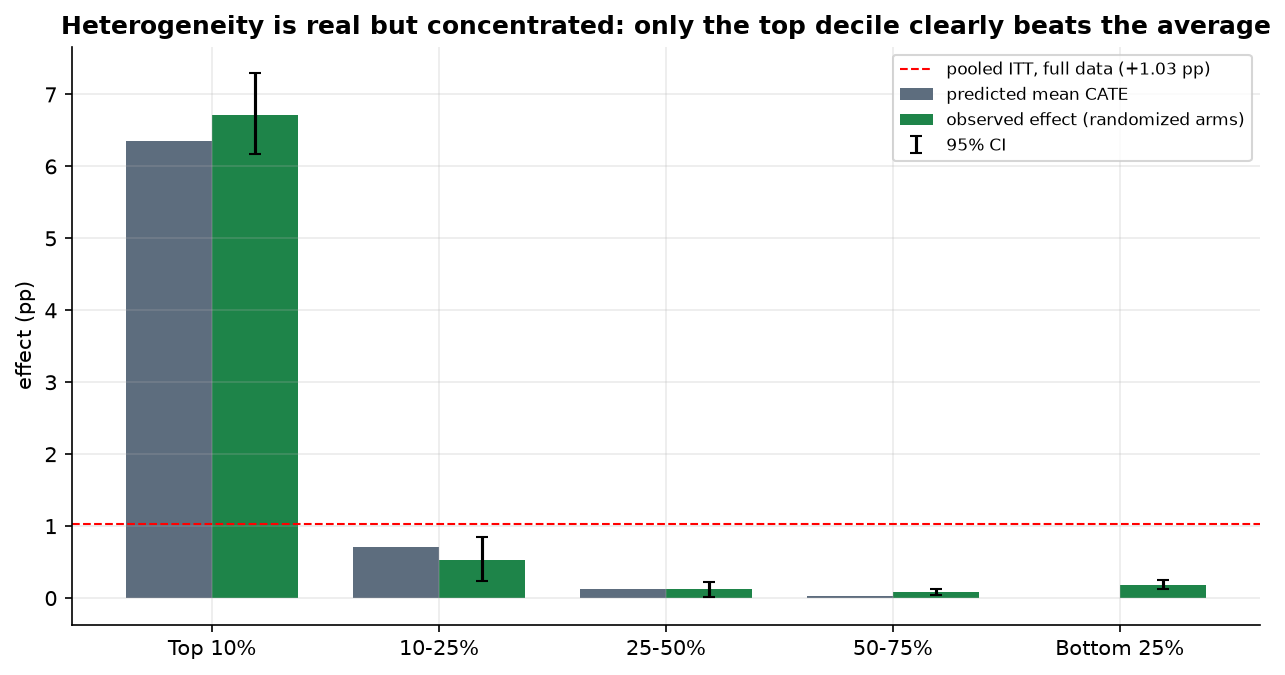

,segment,pred_cate_pp,obs_effect_pp,ci_lo_pp,ci_hi_pp,n,n_treated,n_control
0,Top 10%,6.352,6.721,6.179,7.301,190466,165151,25315
1,10-25%,0.713,0.535,0.238,0.844,285699,242431,43268
2,25-50%,0.132,0.125,0.015,0.227,477212,401844,75368
3,50-75%,0.033,0.081,0.039,0.126,476804,400801,76003
4,Bottom 25%,-0.003,0.186,0.127,0.248,476956,389379,87577


In [11]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))
x = np.arange(len(seg_tab)); w = 0.38
ax.bar(x - w/2, seg_tab.pred_cate_pp, w, color="#5d6d7e", label="predicted mean CATE")
ax.bar(x + w/2, seg_tab.obs_effect_pp, w, color=viz.COLOR_UP, label="observed effect (randomized arms)")
ax.errorbar(x + w/2, seg_tab.obs_effect_pp,
            yerr=[seg_tab.obs_effect_pp - seg_tab.ci_lo_pp, seg_tab.ci_hi_pp - seg_tab.obs_effect_pp],
            fmt="none", ecolor="black", capsize=3, label="95% CI")
ax.set_xticks(x, seg_tab.segment)
ax.set_ylabel("effect (pp)")
ax.axhline(1.034, color="red", ls="--", lw=1, label="pooled ITT, full data (+1.03 pp)")
ax.set_title("Heterogeneity is real but concentrated: only the top decile clearly beats the average")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
viz.savefig(fig, "e6_uplift_segments")
seg_tab